### Conditional Workflow

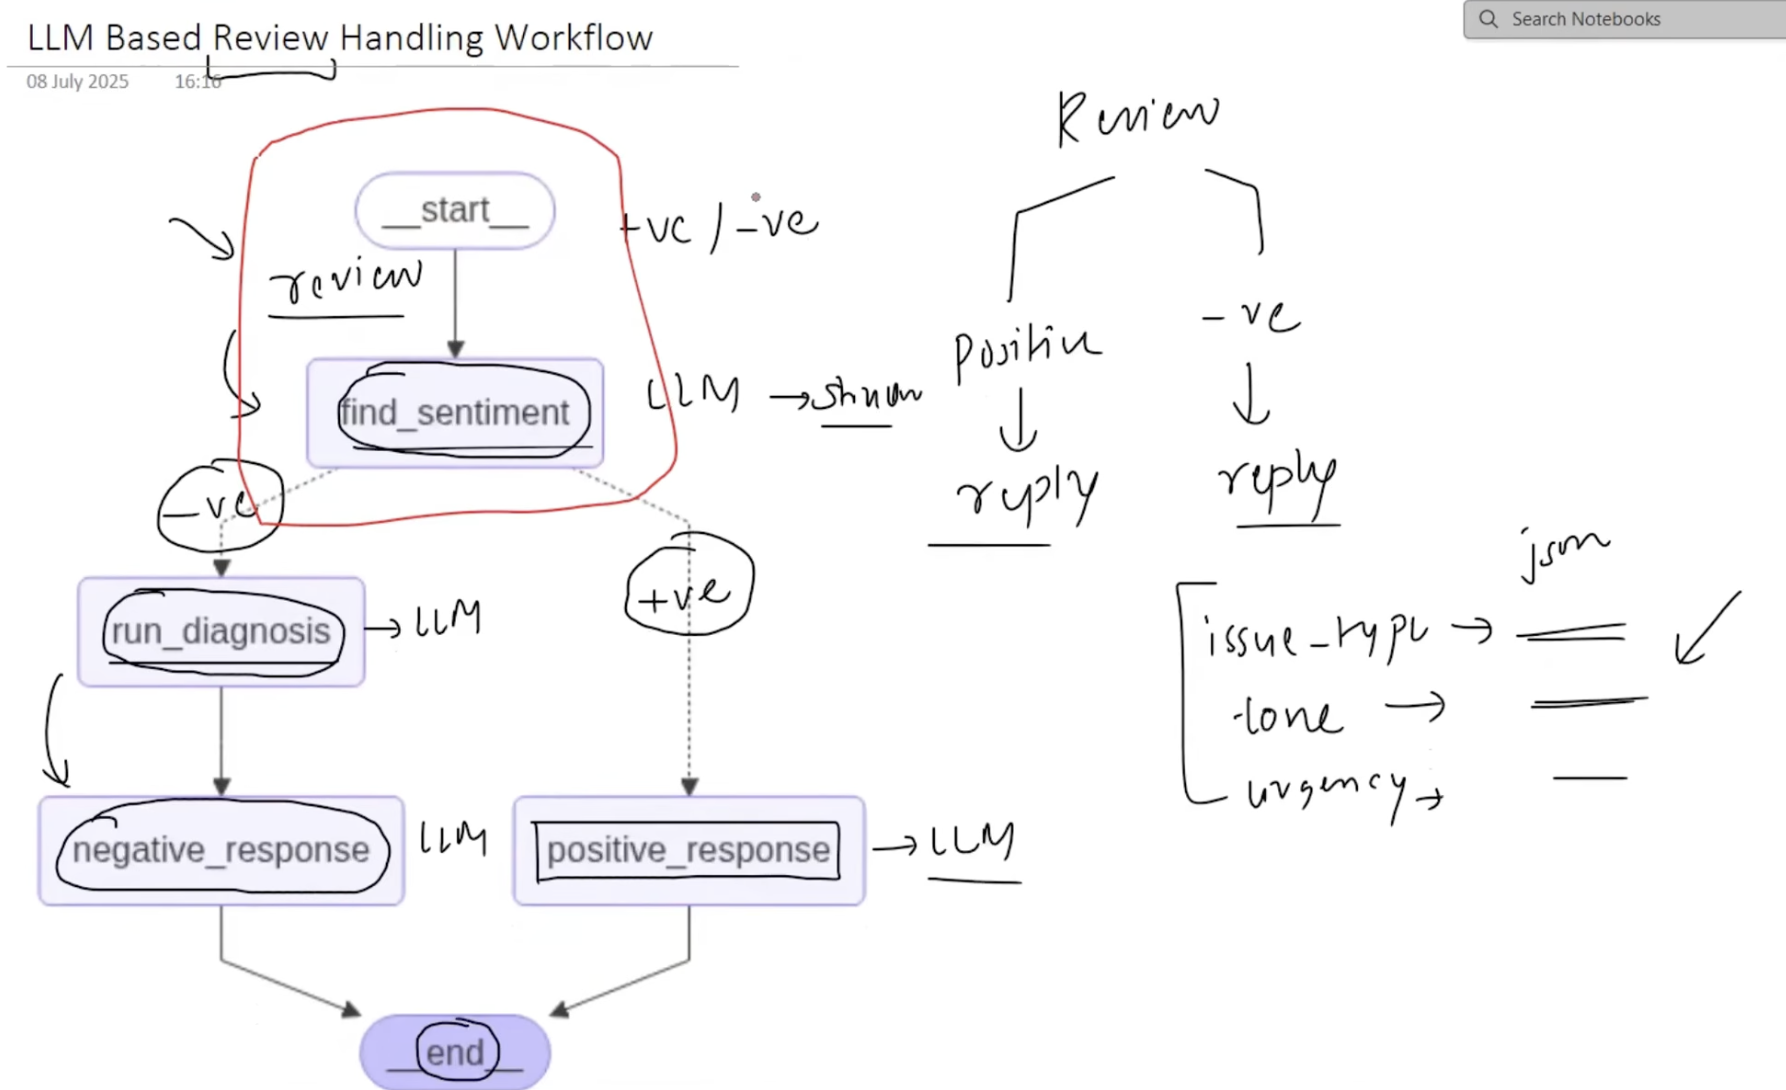

In [24]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict, Literal
from pydantic import BaseModel, Field
from dotenv import load_dotenv

In [25]:
load_dotenv()

True

In [26]:
model = ChatOpenAI(model='gpt-4o-mini')

In [27]:
class SentimentSchema(BaseModel):
    sentiment: Literal['positive', 'negative'] = Field(description='Sentiment of the Review')

In [28]:
class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description="The category of issue mentioned in the review")
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description="The emotional tone expressed by the user")
    urgency: Literal["low", "medium", "high"] = Field(description="How urgent or critical the issue appears to be")

In [29]:
structured_model = model.with_structured_output(SentimentSchema)
structured_model2 = model.with_structured_output(DiagnosisSchema)

In [30]:
prompt = "What is the sentiment of the following review: The software was too good"
structured_model.invoke(prompt) 

SentimentSchema(sentiment='positive')

In [31]:
class ReviewState(TypedDict):
    review: str
    sentiment: Literal['positive', 'negative']
    diagnosis: dict
    response: str


In [32]:
def find_sentiment(state: ReviewState):
    prompt = f"For the following review, find out the sentiment \n {state['review']}"
    sentiment = structured_model.invoke(prompt).sentiment
    return {'sentiment': sentiment}

def check_sentiment(state: ReviewState) -> Literal['positive_response', 'run_diagnosis']:
    if state['sentiment'] == 'positive':
        return 'positive_response'
    else:
        return 'run_diagnosis'

In [33]:
def positive_response(state: ReviewState):
    prompt = f"""Write a warm thank-you message in response to this review:
    \n\n\"{state['review']}\"\n
Also, kindly ask the user to leave feedback on our website."""
    response = model.invoke(prompt).content
    return {'response': response}

def run_diagnosis(state: ReviewState):
    prompt = f"""Diagnose this negative response: \n\n {state['review']} \n
    Return issue_type, tone and urgency."""
    response = structured_model2.invoke(prompt)     # pydantic or json object
    return {'diagnosis': response.model_dump()}     # this will convert the json or pydantic object into a dict and store it in diagnosis

def negative_response(state: ReviewState):
    diagnosis = state['diagnosis']
    prompt = f"""You are a Support Assisstant.
    The user had a '{diagnosis['issue_type']}' issue, sounded like '{diagnosis['tone']}', and marked urgency as '{diagnosis['urgency']}'.
    Write an empathetic, helpful resolution message."""
    response = model.invoke(prompt).content
    return {'response': response}

In [34]:
graph = StateGraph(ReviewState)

graph.add_node('find_sentiment', find_sentiment)
graph.add_node('positive_response', positive_response)
graph.add_node('run_diagnosis', run_diagnosis)
graph.add_node('negative_response', negative_response)

graph.add_edge(START, 'find_sentiment')
graph.add_conditional_edges('find_sentiment', check_sentiment)
graph.add_edge('positive_response', END)
graph.add_edge('run_diagnosis', 'negative_response')
graph.add_edge('negative_response', END)

workflow = graph.compile()

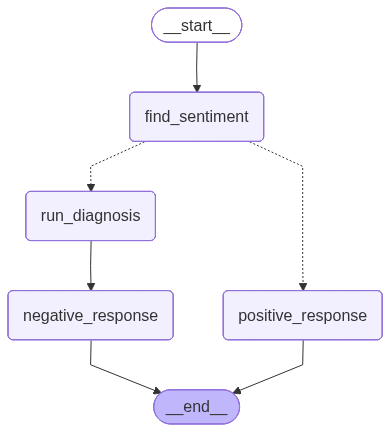

In [35]:
workflow

In [ ]:
intial_state={
    'review': "I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality."
}
workflow.invoke(intial_state)

{'review': 'I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality.',
 'sentiment': 'negative',
 'diagnosis': {'issue_type': 'Bug', 'tone': 'frustrated', 'urgency': 'high'},
 'response': "Subject: We're Here to Help with Your Bug Issue\n\nHi [User's Name],\n\nI hope this message finds you well. I understand that you're experiencing a frustrating bug, and I want to sincerely apologize for any inconvenience this has caused you. I can only imagine how challenging this must be, especially given the urgency you've marked.\n\nRest assured, we are here to help you resolve this issue as quickly as possible. To assist you better, could you please provide a bit more detail about the bug you're encountering? Specific information such as what you were doing when it occurred, any error messages you received, or the device and 

In [ ]:
intial_state={
    'review': ""
}
workflow.invoke(intial_state)